In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')

# FIX 1: Force PyTorch to use CPU instead of MPS (Apple Silicon GPU)
# This prevents "Cannot convert MPS Tensor to float64" error
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
import torch
torch.set_default_dtype(torch.float32)  # Ensure float32 is used

# Force CPU usage - CRITICAL FIX for M1/M2 Macs
if torch.backends.mps.is_available():
    print("MPS detected but forcing CPU usage to avoid float64 issues")
    os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'

# Darts imports
from darts import TimeSeries
from darts.models import (
    NBEATSModel,
    RNNModel,
    ExponentialSmoothing,
    AutoARIMA,
)

# Conditional imports for optional models
try:
    from darts.models import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet not available. Install with: pip install prophet")

try:
    from darts.models import LightGBMModel
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available. Install with: pip install lightgbm")

from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, rmse, mae
from sklearn.model_selection import ParameterGrid

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {'CPU (MPS disabled)' if torch.backends.mps.is_available() else 'CPU'}")


MPS detected but forcing CPU usage to avoid float64 issues
Libraries imported successfully!
PyTorch version: 2.7.0
Using device: CPU (MPS disabled)


In [5]:
# 1. DATA INGESTION

def load_and_prepare_data(filepath='PJME_hourly.csv'):
    """
    Load and prepare the PJME hourly energy consumption dataset
    """
    print("\n" + "="*50)
    print("STEP 1: DATA INGESTION")
    print("="*50)
    
    df = pd.read_csv(filepath)
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    
    df.columns = ['Datetime', 'PJME_MW']
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df = df.sort_values('Datetime').reset_index(drop=True)
    
    print(f"Missing values: {df.isnull().sum().sum()}")
    df = df.dropna()
    
    duplicates = df.duplicated(subset=['Datetime']).sum()
    print(f"Duplicate timestamps: {duplicates}")
    df = df.drop_duplicates(subset=['Datetime'])
    
    df.set_index('Datetime', inplace=True)
    
    print(f"\nDate range: {df.index.min()} to {df.index.max()}")
    print(f"Frequency: {df.index.inferred_freq}")
    print(f"\nBasic Statistics:\n{df['PJME_MW'].describe()}")
    
    return df

In [6]:
# 2. FEATURE ENGINEERING


def create_features(df):
    """
    Create comprehensive feature set for time series forecasting
    """
    print("\n" + "="*50)
    print("STEP 2: FEATURE ENGINEERING")
    print("="*50)
    
    df_features = df.copy()
    
    print("\nCreating temporal features...")
    df_features['hour'] = df_features.index.hour
    df_features['day_of_week'] = df_features.index.dayofweek
    df_features['day_of_month'] = df_features.index.day
    df_features['day_of_year'] = df_features.index.dayofyear
    df_features['month'] = df_features.index.month
    df_features['quarter'] = df_features.index.quarter
    df_features['year'] = df_features.index.year
    df_features['week_of_year'] = df_features.index.isocalendar().week
    
    print("Creating cyclical encodings...")
    df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
    df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)
    df_features['day_sin'] = np.sin(2 * np.pi * df_features['day_of_week'] / 7)
    df_features['day_cos'] = np.cos(2 * np.pi * df_features['day_of_week'] / 7)
    df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
    df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)
    
    df_features['is_weekend'] = (df_features['day_of_week'] >= 5).astype(int)
    df_features['is_business_hours'] = ((df_features['hour'] >= 9) & 
                                        (df_features['hour'] <= 17) & 
                                        (df_features['is_weekend'] == 0)).astype(int)
    
    print("Creating lagged features...")
    lags = [1, 2, 3, 24, 48, 168]
    for lag in lags:
        df_features[f'lag_{lag}'] = df_features['PJME_MW'].shift(lag)
    
    print("Creating rolling statistics...")
    windows = [24, 168, 720]
    for window in windows:
        df_features[f'rolling_mean_{window}'] = df_features['PJME_MW'].rolling(window=window).mean()
        df_features[f'rolling_std_{window}'] = df_features['PJME_MW'].rolling(window=window).std()
        df_features[f'rolling_min_{window}'] = df_features['PJME_MW'].rolling(window=window).min()
        df_features[f'rolling_max_{window}'] = df_features['PJME_MW'].rolling(window=window).max()
    
    print("Creating exponentially weighted features...")
    spans = [24, 168]
    for span in spans:
        df_features[f'ewm_{span}'] = df_features['PJME_MW'].ewm(span=span).mean()
    
    df_features['diff_1'] = df_features['PJME_MW'].diff(1)
    df_features['diff_24'] = df_features['PJME_MW'].diff(24)
    df_features['diff_168'] = df_features['PJME_MW'].diff(168)
    
    initial_rows = len(df_features)
    df_features = df_features.dropna()
    print(f"\nRows after removing NaN: {len(df_features)} (removed {initial_rows - len(df_features)})")
    print(f"Total features created: {len(df_features.columns)}")
    
    return df_features


def prepare_darts_timeseries(df, train_ratio=0.7, val_ratio=0.15):
    """
    Convert to Darts TimeSeries and create train/val/test splits
    """
    print("\n" + "="*50)
    print("STEP 3: PREPARING DARTS TIME SERIES")
    print("="*50)
    
    series = TimeSeries.from_dataframe(
        df,
        value_cols='PJME_MW',
        fill_missing_dates=True,
        freq='H'
    )
    
    n = len(series)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    train = series[:train_end]
    val = series[train_end:val_end]
    test = series[val_end:]
    
    print(f"Total series length: {n}")
    print(f"Train set: {len(train)} samples ({train_ratio*100:.1f}%)")
    print(f"Validation set: {len(val)} samples ({val_ratio*100:.1f}%)")
    print(f"Test set: {len(test)} samples ({(1-train_ratio-val_ratio)*100:.1f}%)")
    
    # Scale the data
    scaler = Scaler()
    train_scaled = scaler.fit_transform(train)
    val_scaled = scaler.transform(val)
    test_scaled = scaler.transform(test)
    
    return {
        'train': train, 'val': val, 'test': test,
        'train_scaled': train_scaled, 'val_scaled': val_scaled, 'test_scaled': test_scaled,
        'scaler': scaler
    }



In [7]:
# 3. MODEL COMPARISON


def train_and_evaluate_models(data_dict, forecast_horizon=168):
    """
    Train multiple models and compare their performance
    """
    print("\n" + "="*50)
    print("STEP 4: MODEL COMPARISON")
    print("="*50)
    
    results = {}
    predictions = {}
    
    train = data_dict['train_scaled']
    val = data_dict['val_scaled']
    scaler = data_dict['scaler']
    
    print(f"\nForecast horizon: {forecast_horizon} hours")
    
    # Model 1: AutoARIMA (always works, no dependencies)
    print("\n--- Training AutoARIMA ---")
    try:
        model_arima = AutoARIMA()
        model_arima.fit(train)
        pred_arima_scaled = model_arima.predict(n=len(val))
        pred_arima = scaler.inverse_transform(pred_arima_scaled)
        
        mape_arima = mape(data_dict['val'], pred_arima)
        rmse_arima = rmse(data_dict['val'], pred_arima)
        mae_arima = mae(data_dict['val'], pred_arima)
        
        results['AutoARIMA'] = {
            'MAPE': mape_arima,
            'RMSE': rmse_arima,
            'MAE': mae_arima,
            'model': model_arima
        }
        predictions['AutoARIMA'] = pred_arima
        print(f"AutoARIMA - MAPE: {mape_arima:.2f}%, RMSE: {rmse_arima:.2f}, MAE: {mae_arima:.2f}")
    except Exception as e:
        print(f"AutoARIMA failed: {e}")
    
    # Model 2: Exponential Smoothing
    print("\n--- Training Exponential Smoothing ---")
    try:
        model_es = ExponentialSmoothing(seasonal_periods=24, trend='add', seasonal='add')
        model_es.fit(train)
        pred_es_scaled = model_es.predict(n=len(val))
        pred_es = scaler.inverse_transform(pred_es_scaled)
        
        mape_es = mape(data_dict['val'], pred_es)
        rmse_es = rmse(data_dict['val'], pred_es)
        mae_es = mae(data_dict['val'], pred_es)
        
        # Check for NaN
        if not np.isnan(mape_es):
            results['ExponentialSmoothing'] = {
                'MAPE': mape_es,
                'RMSE': rmse_es,
                'MAE': mae_es,
                'model': model_es
            }
            predictions['ExponentialSmoothing'] = pred_es
            print(f"Exponential Smoothing - MAPE: {mape_es:.2f}%, RMSE: {rmse_es:.2f}, MAE: {mae_es:.2f}")
        else:
            print("Exponential Smoothing produced NaN - skipping")
    except Exception as e:
        print(f"Exponential Smoothing failed: {e}")
    
    # Model 3: Prophet (if available)
    if PROPHET_AVAILABLE:
        print("\n--- Training Prophet ---")
        try:
            model_prophet = Prophet()
            model_prophet.fit(train)
            pred_prophet_scaled = model_prophet.predict(n=len(val))
            pred_prophet = scaler.inverse_transform(pred_prophet_scaled)
            
            mape_prophet = mape(data_dict['val'], pred_prophet)
            rmse_prophet = rmse(data_dict['val'], pred_prophet)
            mae_prophet = mae(data_dict['val'], pred_prophet)
            
            results['Prophet'] = {
                'MAPE': mape_prophet,
                'RMSE': rmse_prophet,
                'MAE': mae_prophet,
                'model': model_prophet
            }
            predictions['Prophet'] = pred_prophet
            print(f"Prophet - MAPE: {mape_prophet:.2f}%, RMSE: {rmse_prophet:.2f}, MAE: {mae_prophet:.2f}")
        except Exception as e:
            print(f"Prophet failed: {e}")
    
    # Model 4: NBEATS (with CPU forcing)
    print("\n--- Training NBEATS ---")
    try:
        model_nbeats = NBEATSModel(
            input_chunk_length=168,
            output_chunk_length=24,
            n_epochs=30,  # Reduced for faster training
            batch_size=32,
            random_state=42,
            pl_trainer_kwargs={
                "accelerator": "cpu",  # FORCE CPU
                "enable_progress_bar": False
            }
        )
        model_nbeats.fit(train, verbose=False)
        pred_nbeats_scaled = model_nbeats.predict(n=len(val))
        pred_nbeats = scaler.inverse_transform(pred_nbeats_scaled)
        
        mape_nbeats = mape(data_dict['val'], pred_nbeats)
        rmse_nbeats = rmse(data_dict['val'], pred_nbeats)
        mae_nbeats = mae(data_dict['val'], pred_nbeats)
        
        results['NBEATS'] = {
            'MAPE': mape_nbeats,
            'RMSE': rmse_nbeats,
            'MAE': mae_nbeats,
            'model': model_nbeats
        }
        predictions['NBEATS'] = pred_nbeats
        print(f"NBEATS - MAPE: {mape_nbeats:.2f}%, RMSE: {rmse_nbeats:.2f}, MAE: {mae_nbeats:.2f}")
    except Exception as e:
        print(f"NBEATS failed: {e}")
    
    # Model 5: LSTM (with CPU forcing)
    print("\n--- Training LSTM ---")
    try:
        model_lstm = RNNModel(
            model="LSTM",
            input_chunk_length=168,
            training_length=168,
            n_epochs=30,  # Reduced for faster training
            batch_size=32,
            hidden_dim=64,  # Reduced for faster training
            n_rnn_layers=1,
            dropout=0.2,
            random_state=42,
            pl_trainer_kwargs={
                "accelerator": "cpu",  # FORCE CPU
                "enable_progress_bar": False
            }
        )
        model_lstm.fit(train, verbose=False)
        pred_lstm_scaled = model_lstm.predict(n=len(val))
        pred_lstm = scaler.inverse_transform(pred_lstm_scaled)
        
        mape_lstm = mape(data_dict['val'], pred_lstm)
        rmse_lstm = rmse(data_dict['val'], pred_lstm)
        mae_lstm = mae(data_dict['val'], pred_lstm)
        
        results['LSTM'] = {
            'MAPE': mape_lstm,
            'RMSE': rmse_lstm,
            'MAE': mae_lstm,
            'model': model_lstm
        }
        predictions['LSTM'] = pred_lstm
        print(f"LSTM - MAPE: {mape_lstm:.2f}%, RMSE: {rmse_lstm:.2f}, MAE: {mae_lstm:.2f}")
    except Exception as e:
        print(f"LSTM failed: {e}")
    
    # Model 6: LightGBM (if available)
    if LIGHTGBM_AVAILABLE:
        print("\n--- Training LightGBM ---")
        try:
            model_lgb = LightGBMModel(
                lags=168,
                lags_past_covariates=None,
                output_chunk_length=24,
                random_state=42
            )
            model_lgb.fit(train, verbose=False)
            pred_lgb_scaled = model_lgb.predict(n=len(val))
            pred_lgb = scaler.inverse_transform(pred_lgb_scaled)
            
            mape_lgb = mape(data_dict['val'], pred_lgb)
            rmse_lgb = rmse(data_dict['val'], pred_lgb)
            mae_lgb = mae(data_dict['val'], pred_lgb)
            
            results['LightGBM'] = {
                'MAPE': mape_lgb,
                'RMSE': rmse_lgb,
                'MAE': mae_lgb,
                'model': model_lgb
            }
            predictions['LightGBM'] = pred_lgb
            print(f"LightGBM - MAPE: {mape_lgb:.2f}%, RMSE: {rmse_lgb:.2f}, MAE: {mae_lgb:.2f}")
        except Exception as e:
            print(f"LightGBM failed: {e}")
    
    # Summary
    print("\n" + "="*50)
    print("MODEL COMPARISON SUMMARY")
    print("="*50)
    
    if len(results) > 0:
        results_df = pd.DataFrame(results).T
        results_df = results_df[['MAPE', 'RMSE', 'MAE']].sort_values('MAPE')
        print(results_df)
        
        best_model_name = results_df.index[0]
        print(f"\nBest Model: {best_model_name} (Lowest MAPE: {results_df.loc[best_model_name, 'MAPE']:.2f}%)")
    else:
        print("No models succeeded!")
        results_df = pd.DataFrame()
    
    return results, predictions, results_df


In [8]:
# 4. HYPERPARAMETER TUNING


def tune_nbeats(data_dict, param_grid=None):
    """
    Hyperparameter tuning for NBEATS model
    """
    print("\n" + "="*50)
    print("STEP 5: HYPERPARAMETER TUNING (NBEATS)")
    print("="*50)
    
    train = data_dict['train_scaled']
    val = data_dict['val_scaled']
    scaler = data_dict['scaler']
    
    if param_grid is None:
        # Smaller grid for faster execution
        param_grid = {
            'input_chunk_length': [168],
            'output_chunk_length': [24],
            'n_epochs': [20, 30],
            'batch_size': [32],
            'num_blocks': [3],
            'num_layers': [2, 4]
        }
    
    print(f"Grid search with {np.prod([len(v) for v in param_grid.values()])} combinations")
    
    best_mape = float('inf')
    best_params = None
    best_model = None
    results_list = []
    
    for params in ParameterGrid(param_grid):
        try:
            model = NBEATSModel(
                input_chunk_length=params['input_chunk_length'],
                output_chunk_length=params['output_chunk_length'],
                n_epochs=params['n_epochs'],
                batch_size=params['batch_size'],
                num_blocks=params['num_blocks'],
                num_layers=params['num_layers'],
                random_state=42,
                pl_trainer_kwargs={
                    "accelerator": "cpu",  # FORCE CPU
                    "enable_progress_bar": False
                }
            )
            
            model.fit(train, verbose=False)
            pred_scaled = model.predict(n=len(val))
            pred = scaler.inverse_transform(pred_scaled)
            
            mape_score = mape(data_dict['val'], pred)
            
            results_list.append({
                **params,
                'MAPE': mape_score
            })
            
            if mape_score < best_mape:
                best_mape = mape_score
                best_params = params
                best_model = model
                
            print(f"Params: {params} | MAPE: {mape_score:.2f}%")
            
        except Exception as e:
            print(f"Failed with params {params}: {e}")
            continue
    
    print("\n" + "="*50)
    print("BEST HYPERPARAMETERS")
    print("="*50)
    
    if len(results_list) > 0:
        print(f"Best MAPE: {best_mape:.2f}%")
        print(f"Best Parameters: {best_params}")
        
        results_df = pd.DataFrame(results_list).sort_values('MAPE')
        print(f"\nTop configurations:")
        print(results_df.head())
    else:
        print("No successful hyperparameter combinations")
        results_df = pd.DataFrame()
    
    return best_model, best_params, results_df


In [9]:
# 5. VISUALIZATION


def plot_predictions(data_dict, predictions):
    """
    Plot predictions vs actual values for all models
    """
    if len(predictions) == 0:
        print("No predictions to plot")
        return
        
    print("\n" + "="*50)
    print("STEP 6: VISUALIZATION")
    print("="*50)
    
    actual = data_dict['val']
    
    fig, axes = plt.subplots(len(predictions), 1, figsize=(15, 4*len(predictions)))
    if len(predictions) == 1:
        axes = [axes]
    
    for idx, (model_name, pred) in enumerate(predictions.items()):
        ax = axes[idx]
        
        actual.plot(ax=ax, label='Actual', linewidth=2, color='black')
        pred.plot(ax=ax, label=f'{model_name} Prediction', linewidth=2, linestyle='--')
        
        mape_score = mape(actual, pred)
        rmse_score = rmse(actual, pred)
        
        ax.set_title(f'{model_name} - MAPE: {mape_score:.2f}%, RMSE: {rmse_score:.2f}', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Energy Consumption (MW)', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_predictions_comparison.png', dpi=300, bbox_inches='tight')
    print("Saved: model_predictions_comparison.png")
    plt.show()


def plot_forecast_detail(data_dict, model, model_name, forecast_days=7):
    """
    Detailed forecast plot
    """
    scaler = data_dict['scaler']
    train = data_dict['train_scaled']
    test = data_dict['test']
    
    forecast_hours = forecast_days * 24
    pred_scaled = model.predict(n=min(forecast_hours, len(test)))
    pred = scaler.inverse_transform(pred_scaled)
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    train_display = scaler.inverse_transform(train[-336:])
    train_display.plot(ax=ax, label='Historical', linewidth=2, color='blue')
    
    actual_test = test[:len(pred)]
    actual_test.plot(ax=ax, label='Actual', linewidth=2, color='black')
    
    pred.plot(ax=ax, label=f'{model_name} Forecast', linewidth=2, 
              linestyle='--', color='red')
    
    mape_score = mape(actual_test, pred)
    rmse_score = rmse(actual_test, pred)
    mae_score = mae(actual_test, pred)
    
    ax.set_title(f'{model_name} {forecast_days}-Day Forecast\nMAPE: {mape_score:.2f}%, RMSE: {rmse_score:.2f}, MAE: {mae_score:.2f}', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Energy Consumption (MW)', fontsize=12)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_forecast_detail.png', dpi=300, bbox_inches='tight')
    print(f"Saved: {model_name.lower()}_forecast_detail.png")
    plt.show()
    
    return pred, mape_score, rmse_score, mae_score


def plot_feature_importance_analysis(df):
    """
    Analyze temporal patterns
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    hourly_avg = df.groupby(df.index.hour)['PJME_MW'].mean()
    axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
    axes[0, 0].set_title('Average Energy Consumption by Hour', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Energy (MW)')
    axes[0, 0].grid(True, alpha=0.3)
    
    daily_avg = df.groupby(df.index.dayofweek)['PJME_MW'].mean()
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[0, 1].bar(range(7), daily_avg.values)
    axes[0, 1].set_xticks(range(7))
    axes[0, 1].set_xticklabels(day_names)
    axes[0, 1].set_title('Average Energy Consumption by Day of Week', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Energy (MW)')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    monthly_avg = df.groupby(df.index.month)['PJME_MW'].mean()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    axes[1, 0].plot(range(1, 13), monthly_avg.values, marker='o', linewidth=2)
    axes[1, 0].set_xticks(range(1, 13))
    axes[1, 0].set_xticklabels(month_names, rotation=45)
    axes[1, 0].set_title('Average Energy Consumption by Month', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Energy (MW)')
    axes[1, 0].grid(True, alpha=0.3)
    
    yearly_avg = df.resample('M')['PJME_MW'].mean()
    axes[1, 1].plot(yearly_avg.index, yearly_avg.values, linewidth=2)
    axes[1, 1].set_title('Monthly Average Energy Consumption Trend', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Energy (MW)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('temporal_patterns.png', dpi=300, bbox_inches='tight')
    print("Saved: temporal_patterns.png")
    plt.show()



 ENERGY CONSUMPTION FORECASTING WITH DARTS
 PJME Hourly Energy Consumption Dataset

STEP 1: DATA INGESTION
Dataset loaded: 145366 rows, 2 columns
Missing values: 0
Duplicate timestamps: 4

Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Frequency: None

Basic Statistics:
count    145362.000000
mean      32080.510780
std        6463.866507
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64
Saved: temporal_patterns.png


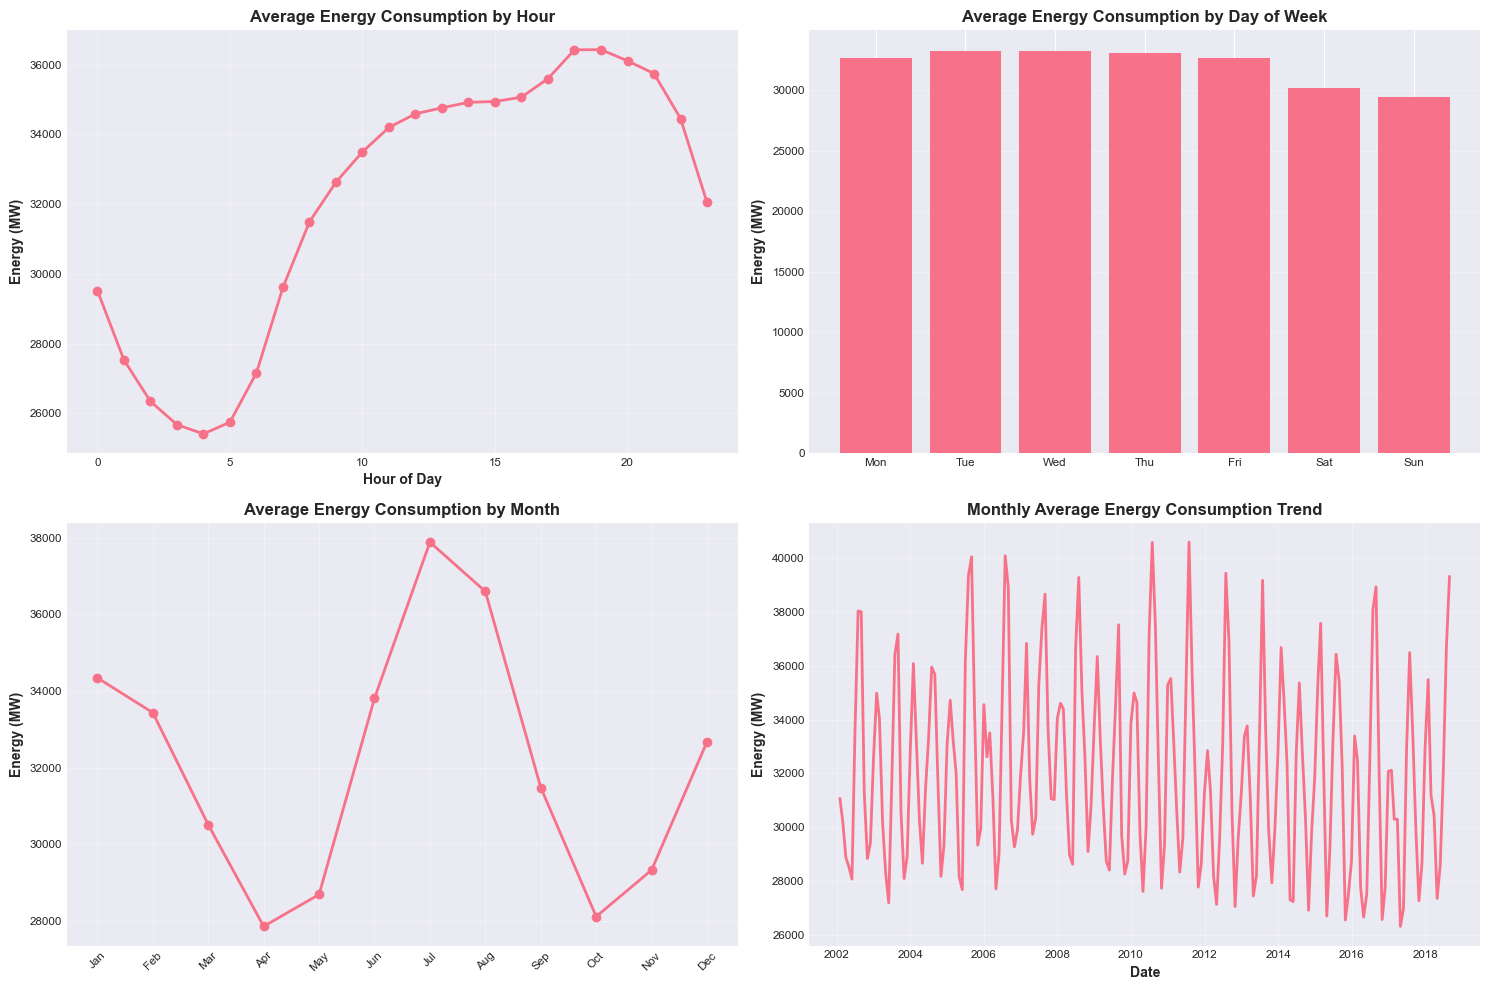


STEP 2: FEATURE ENGINEERING

Creating temporal features...
Creating cyclical encodings...
Creating lagged features...
Creating rolling statistics...
Creating exponentially weighted features...

Rows after removing NaN: 144643 (removed 719)
Total features created: 40

STEP 3: PREPARING DARTS TIME SERIES


ImportError: The `StatsForecast` module could not be imported. To enable StatsForecast support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


Total series length: 145392
Train set: 101774 samples (70.0%)
Validation set: 21809 samples (15.0%)
Test set: 21809 samples (15.0%)

STEP 4: MODEL COMPARISON

Forecast horizon: 168 hours

--- Training AutoARIMA ---
AutoARIMA failed: The `StatsForecast` module could not be imported. To enable StatsForecast support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md

--- Training Exponential Smoothing ---
Exponential Smoothing failed: 'str' object has no attribute 'value'

--- Training Prophet ---


18:09:10 - cmdstanpy - INFO - Chain [1] start processing
18:09:34 - cmdstanpy - INFO - Chain [1] done processing
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Prophet - MAPE: 9.39%, RMSE: 3999.76, MAE: 3021.63

--- Training NBEATS ---



Detected KeyboardInterrupt, attempting graceful shutdown ...
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


NBEATS failed: name 'exit' is not defined

--- Training LSTM ---



Detected KeyboardInterrupt, attempting graceful shutdown ...


LSTM failed: name 'exit' is not defined

--- Training LightGBM ---
LightGBM failed: Input y contains NaN.

MODEL COMPARISON SUMMARY
             MAPE         RMSE          MAE
Prophet  9.391479  3999.757668  3021.629644

Best Model: Prophet (Lowest MAPE: 9.39%)

STEP 6: VISUALIZATION
Saved: model_predictions_comparison.png


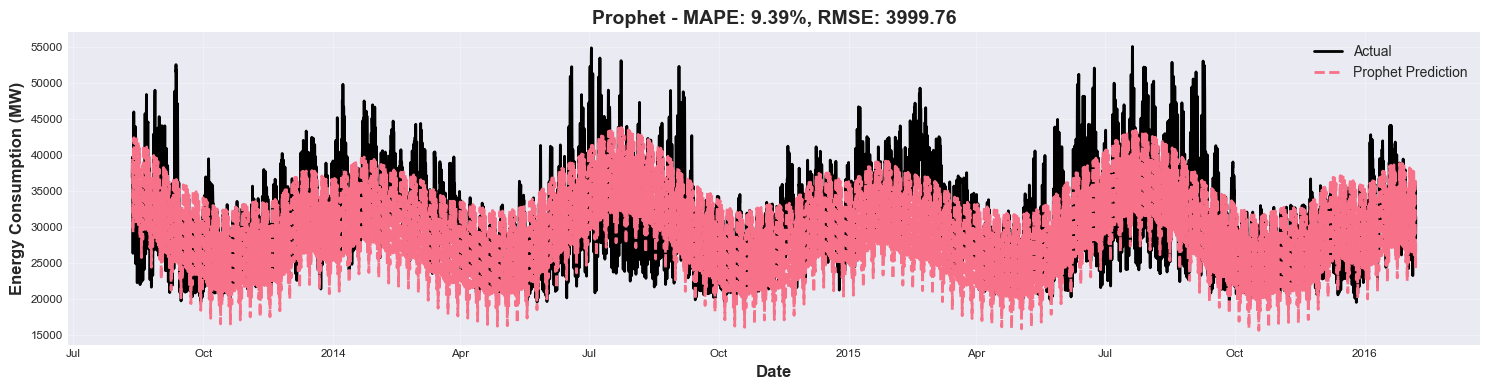


Skipping hyperparameter tuning - no successful models

 PIPELINE COMPLETED!


In [10]:
# MAIN EXECUTION PIPELINE


def main():
    """
    Main execution pipeline
    """
    print("\n" + "="*70)
    print(" ENERGY CONSUMPTION FORECASTING WITH DARTS")
    print(" PJME Hourly Energy Consumption Dataset")
    print("="*70)
    
    df = load_and_prepare_data('PJME_hourly.csv')
    plot_feature_importance_analysis(df)
    
    df_features = create_features(df)
    data_dict = prepare_darts_timeseries(df, train_ratio=0.7, val_ratio=0.15)
    
    results, predictions, results_df = train_and_evaluate_models(data_dict, forecast_horizon=168)
    
    plot_predictions(data_dict, predictions)
    
    # Hyperparameter tuning only if models succeeded
    if len(results) > 0 and 'NBEATS' in results:
        print("\n\nPerforming hyperparameter tuning...")
        param_grid_nbeats = {
            'input_chunk_length': [168],
            'output_chunk_length': [24],
            'n_epochs': [20, 30],
            'batch_size': [32],
            'num_blocks': [3],
            'num_layers': [2, 4]
        }
        best_nbeats, best_params_nbeats, tuning_results_nbeats = tune_nbeats(data_dict, param_grid_nbeats)
        
        if best_nbeats is not None:
            print("\n" + "="*50)
            print("FINAL EVALUATION ON TEST SET")
            print("="*50)
            pred_nbeats, mape_nb, rmse_nb, mae_nb = plot_forecast_detail(
                data_dict, best_nbeats, 'NBEATS_Tuned', forecast_days=7
            )
    else:
        best_nbeats = None
        print("\nSkipping hyperparameter tuning - no successful models")
    
    print("\n" + "="*70)
    print(" PIPELINE COMPLETED!")
    print("="*70)
    
    return df, df_features, data_dict, results, predictions, best_nbeats


if __name__ == "__main__":
    df, df_features, data_dict, results, predictions, best_model = main()